# Application 1 — Confocal microscopy: *C. elegans* nuclei

**Modality:** confocal fluorescence microscopy (3D). **Objects:** cell nuclei of a *C. elegans* larva.

**Dataset:** Long, F., Peng, H., Liu, X., Kim, S. K., Myers, E., Kainmüller, D. and Weigert, M. (2022).
*3D nuclei instance segmentation dataset of fluorescence microscopy volumes of C. elegans.* Zenodo,
[doi:10.5281/zenodo.5942575](https://doi.org/10.5281/zenodo.5942575). Licence CC-BY-4.0.
The data record asks users to cite Long et al. (2009), *Nat. Methods* 6:667–672 (raw data); the curated instance masks are from
Hirsch and Kainmüller (2020, MIDL), the train/validation/test split from Weigert et al. (2020, WACV).

**What this notebook does:** downloads the archive once (84 MB, checked against its MD5), extracts the first training volume and its
instance masks, derives one 3D box per nucleus, loads all boxes into the synchronized four-viewer layout of napari-TurboBox,
replays a mouse drag on one box, and exports the boxes as native, COCO and YOLO files.
The same steps work for your own data with `examples/labels_to_boxes.py`.

In [1]:
SHOW = False  # True: open the four napari windows (needs a desktop session)

if SHOW:
    get_ipython().run_line_magic("gui", "qt")

import json
from pathlib import Path

import numpy as np
from IPython.display import Image, display

import tutorial_utils as tu

CASE = "01_confocal_celegans_nuclei"
DATA = tu.data_dir('celegans_nuclei')  # $TURBOBOX_DATA/<subdir>, else ~/.cache/napari-turbobox/<subdir>
OUT = DATA / "export"
print("data directory:", tu.show_path(DATA))

data directory: ~/.cache/napari-turbobox/celegans_nuclei


## 1. Download


The archive is downloaded into the data directory only if it is not there yet, and verified against the size and MD5 published by Zenodo.
Only the first training volume and its mask are extracted.

In [2]:
ZIP_URL = "https://zenodo.org/api/records/5942575/files/c_elegans_nuclei.zip/content"
archive = tu.fetch(ZIP_URL, DATA / "c_elegans_nuclei.zip", size=84_403_531, md5="7d616d91c4a6cce75a7d4dd37d7e666a")
raw_path = tu.extract_member(archive, "c_elegans_nuclei/train/images/C18G1_2L1_1.tif", DATA / "C18G1_2L1_1_raw.tif")
gt_path = tu.extract_member(archive, "c_elegans_nuclei/train/masks/C18G1_2L1_1.tif", DATA / "C18G1_2L1_1_masks.tif")

## 2. Load the volume


`tifffile` returns both volumes with shape `(140, 140, 1244)`, used as `(z, y, x)`; the worm lies along x.
The record gives no voxel size, so the volume is shown with unit scale.

In [3]:
import tifffile

image = tifffile.imread(raw_path)
labels = tifffile.imread(gt_path)
SCALE = None  # voxel size (z, y, x); None = unit scale
CONTRAST = None  # napari's automatic contrast limits
print("image", image.shape, image.dtype, "| masks", labels.shape, labels.dtype, "|", len(np.unique(labels)) - 1, "labels")

image (140, 140, 1244) uint8 | masks (140, 140, 1244) uint32 | 555 labels


## 3. One box per object


Each nucleus becomes the box from its first to its last voxel index on every axis (`scipy.ndimage.find_objects`).
A nucleus that is one voxel thick along an axis is widened to an extent of one, the minimum the plugin accepts.

In [4]:
boxes, ids = tu.labels_to_boxes(labels)
print(len(boxes), "boxes from", len(ids), "labels")

555 boxes from 555 labels


In [5]:
check = tu.check_boxes(boxes, image.shape)
print(f"{check['valid']} of {check['boxes']} boxes satisfy 0 <= min, max <= shape - 1, max - min >= 1")
extent = boxes[:, 1] - boxes[:, 0]
print("median box extent (z, y, x) in voxels:", np.median(extent, axis=0).tolist())

555 of 555 boxes satisfy 0 <= min, max <= shape - 1, max - min >= 1
median box extent (z, y, x) in voxels: [12.0, 10.0, 12.0]


## 4. The synchronized four-viewer layout

XY is the editable view; XZ, YZ and 3D are read-only and display the same box store.
`add_boxes` validates every box against the image shape, so a `ValueError` here would mean an invalid box.
The screenshot shows the four canvases (XY, XZ, YZ, 3D), each 2D view on a slice through one median-sized box.

555 boxes in the shared store; shapes drawn per view: [168, 142, 16, 555]


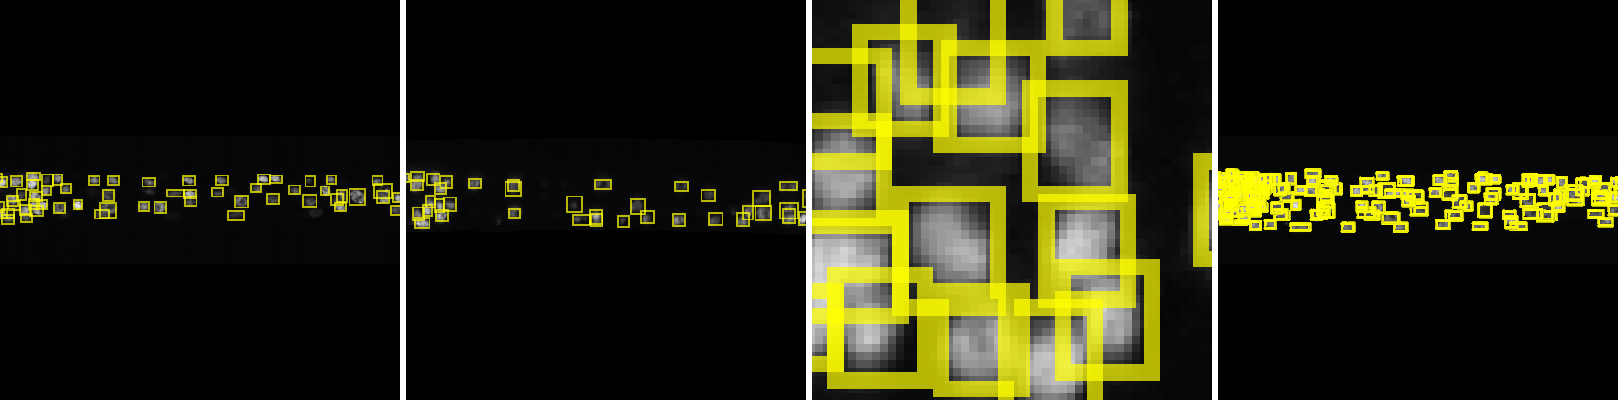

In [6]:
k = tu.pick_box(boxes)
viewers, layers = tu.four_viewer_layout(
    image, boxes, show=SHOW, scale=SCALE, contrast_limits=CONTRAST, focus_box=k
)
print(len(layers[0].bounding_boxes), "boxes in the shared store;",
      "shapes drawn per view:", [lyr.nshapes for lyr in layers])
shot = tu.RESULTS / f"{CASE}_views.png"
tu.screenshot(viewers, shot)
display(Image(filename=str(shot)))

## 5. Replaying a mouse drag

The drag below goes through napari's own mouse-event dispatch, the same path as a real mouse:
it grabs box `k` in the XY view at its centre and moves it by a quarter of its size in y and x.
We check that the box stays a valid box, that the read-only XZ and YZ views and the 3D view show it at the new position,
and that one undo step restores it.

In [7]:
drag = tu.replay_drag(viewers, layers, k)
print("shift (z, y, x):", drag["shift_zyx"], "intended:", drag["intended_shift_zyx"])
print("still a valid box:", drag["valid"])
print("read-only views show the moved box:", drag["views_show_moved_box"])
layers[0].undo()
print("undo restores all boxes:", np.array_equal(layers[0].bounding_boxes, boxes.astype(np.float32)))

shift (z, y, x): [0.0, 2.0, 3.0] intended: [0.0, 2.0, 3.0]
still a valid box: True
read-only views show the moved box: {'XZ (read-only)': True, 'YZ (read-only)': True, '3D (read-only)': True}


undo restores all boxes: True


## 6. Export

Native `boxes.npy` (the format of the control panel's import/export), COCO JSON with one 2D box per slice that a 3D box covers,
and one YOLO label file per slice. Slice images are named `slice_NNNN.png`; the exporter writes no image files.

In [8]:
counts = tu.export(layers[0].bounding_boxes, image.shape, OUT, label_ids=ids)
print(json.dumps(counts, indent=1))
print("files in", tu.show_path(OUT), ":", sorted(p.name for p in OUT.iterdir()))

{
 "boxes": 555,
 "coco_images": 64,
 "coco_annotations": 7262,
 "yolo_files": 64
}
files in ~/.cache/napari-turbobox/celegans_nuclei/export : ['boxes.npy', 'coco_per_slice.json', 'label_ids.npy', 'yolo']


In [9]:
result = dict(
    case=CASE,
    modality="confocal fluorescence microscopy",
    objects="nuclei (instance masks)",
    dataset="Long et al. 2022, Zenodo, doi:10.5281/zenodo.5942575 (CC-BY-4.0)",
    volume="c_elegans_nuclei/train/images/C18G1_2L1_1.tif",
    box_source="ground-truth instance masks",
)
result.update(check=check, export=counts, drag=drag, image_shape=list(image.shape), n_boxes=int(len(boxes)))
print(json.dumps({k: v for k, v in result.items() if k != "drag"}, indent=1))
tu.show_path(tu.save_result(CASE, result))

{
 "case": "01_confocal_celegans_nuclei",
 "modality": "confocal fluorescence microscopy",
 "objects": "nuclei (instance masks)",
 "dataset": "Long et al. 2022, Zenodo, doi:10.5281/zenodo.5942575 (CC-BY-4.0)",
 "volume": "c_elegans_nuclei/train/images/C18G1_2L1_1.tif",
 "box_source": "ground-truth instance masks",
 "check": {
  "boxes": 555,
  "valid": 555
 },
 "export": {
  "boxes": 555,
  "coco_images": 64,
  "coco_annotations": 7262,
  "yolo_files": 64
 },
 "image_shape": [
  140,
  140,
  1244
 ],
 "n_boxes": 555
}


'tutorials/results/01_confocal_celegans_nuclei.json'

In [10]:
if not SHOW:
    for v in viewers:
        v.close()